# AEGIS-Dengue — exploratory data analysis

Descriptive figures introducing the assembled dataset, for the project proposal.

Everything here reads the master panel `data/processed/panel_weekly.parquet`
(built by `scripts/10.create_master_panel.py`), the node registry
`data/processed/nodes.csv`, the district graph `data/processed/adjacency.npz`,
and the GADM boundaries `data/raw/gadm41_LKA_1.json`. Nothing is recomputed
from the raw sources and nothing is written back to `data/`.

Each figure is also saved as a 200 dpi PNG into `results/eda/` so it can be
dropped straight into the proposal document.

**This notebook is descriptive only.** No imputation, no lags, no
train/test split — those live in scripts 11–14 and are fitted per fold there.
The whole series is summarised here, which is legitimate for describing a
dataset and would be leakage if it fed a model.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGDIR = ROOT / "results" / "eda"
FIGDIR.mkdir(parents=True, exist_ok=True)
print(ROOT)

c:\Users\User\Desktop\AEGIS-Dengue


## Plot style

One palette for every figure. The hues are a colour-vision-deficiency-validated
set: blue and aqua are the two categorical slots used, and the blue ramp is the
single-hue sequential scale for the choropleth and the heatmap.

In [2]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
             "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281",
             "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("aegis_blue", BLUE_RAMP)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 9.5, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelsize": 9.5, "axes.labelcolor": INK2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "legend.frameon": False, "legend.fontsize": 8.5,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

MON = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    print("saved", (FIGDIR / f"{name}.png").relative_to(ROOT))

## Load

In [3]:
panel = pd.read_parquet(ROOT / "data/processed/panel_weekly.parquet")
nodes = pd.read_csv(ROOT / "data/processed/nodes.csv")
gdf = gpd.read_file(ROOT / "data/raw/gadm41_LKA_1.json")
adj = np.load(ROOT / "data/processed/adjacency.npz", allow_pickle=True)
A = adj["A_binary"]

N_PANEL_COLS = panel.shape[1]  # before the two derived columns below
panel["month"] = panel["start_date"].dt.month
panel["year"] = panel["start_date"].dt.year

print(panel.shape)
panel.head(3)

(25300, 35)


,period_id,source_year,source_week,start_date,end_date,reporting_days,weekday_convention,is_weekday_convention_change,is_irregular_period,calendar_gap_before_days,...,weather_days_available,weather_coverage_ratio,weather_complete,row_has_complete_cases,row_has_complete_climate,row_is_fully_observed,is_covid_window,is_2017_outbreak,month,year
0,1,2006,52,2006-12-23,2006-12-29,7,saturday_friday,False,False,0,...,7,1.0,True,1,1,1,0,0,12,2006
1,1,2006,52,2006-12-23,2006-12-29,7,saturday_friday,False,False,0,...,7,1.0,True,1,1,1,0,0,12,2006
2,1,2006,52,2006-12-23,2006-12-29,7,saturday_friday,False,False,0,...,7,1.0,True,1,1,1,0,0,12,2006


## Dataset at a glance

The numbers below are computed from the panel itself, so the table stays true
if the data is rebuilt or extended.

In [4]:
n_missing_cases = int(panel["cases"].isna().sum())
n_missing_clim = int((~panel["weather_complete"]).sum())
clim_gap = panel.loc[~panel["weather_complete"], "period_id"].unique()
rows = [
    ("Spatial units", f"{panel.node_id.nunique()} canonical districts "
                      f"across {panel.province.nunique()} provinces"),
    ("Time index", f"{panel.period_id.nunique():,} reporting periods, "
                   f"{panel.start_date.min():%Y-%m-%d} to {panel.end_date.max():%Y-%m-%d}"),
    ("Panel size", f"{len(panel):,} district-period rows x {N_PANEL_COLS} columns"),
    ("Period length", f"{panel.reporting_days.min()}-{panel.reporting_days.max()} days "
                      f"({(panel.reporting_days != 7).sum() // 25} irregular periods)"),
    ("Dengue source", "denguedatahub weekly Sri Lanka series (26 reporting areas "
                      "merged to 25 districts)"),
    ("Climate source", "ERA5-Land hourly, reduced to daily, area-weighted per "
                       "district, aggregated over each reporting period"),
    ("Rainfall cross-check", "CHIRPS daily (scripts 7-8)"),
    ("Boundaries / graph", f"GADM 4.1 ADM1; queen contiguity, "
                           f"{A.shape[0]} nodes / {int(A.sum() // 2)} edges, "
                           f"mean degree {A.sum(1).mean():.2f}"),
    ("Total reported cases", f"{panel.cases.sum():,.0f}"),
    ("Missing case records", f"{n_missing_cases} of {len(panel):,} "
                             f"({n_missing_cases / len(panel):.4%})"),
    ("Missing climate records", f"{n_missing_clim} of {len(panel):,} "
                                f"({n_missing_clim / len(panel):.2%}) — periods "
                                f"{clim_gap.min()}-{clim_gap.max()}, beyond the "
                                f"end of the ERA5 extraction"),
]
display(Markdown("| | |\n|---|---|\n"
                 + "\n".join(f"| **{k}** | {v} |" for k, v in rows)))

| | |
|---|---|
| **Spatial units** | 25 canonical districts across 9 provinces |
| **Time index** | 1,012 reporting periods, 2006-12-23 to 2026-05-17 |
| **Panel size** | 25,300 district-period rows x 33 columns |
| **Period length** | 6-8 days (2 irregular periods) |
| **Dengue source** | denguedatahub weekly Sri Lanka series (26 reporting areas merged to 25 districts) |
| **Climate source** | ERA5-Land hourly, reduced to daily, area-weighted per district, aggregated over each reporting period |
| **Rainfall cross-check** | CHIRPS daily (scripts 7-8) |
| **Boundaries / graph** | GADM 4.1 ADM1; queen contiguity, 25 nodes / 57 edges, mean degree 4.56 |
| **Total reported cases** | 833,559 |
| **Missing case records** | 1 of 25,300 (0.0040%) |
| **Missing climate records** | 75 of 25,300 (0.30%) — periods 1010-1012, beyond the end of the ERA5 extraction |

## Figure 1 — the national series

The whole target variable in one picture: 1 012 reporting periods of national
case counts, and the same data as annual totals.

Two things a forecasting proposal needs to state up front. The 2017 epidemic is
an order of magnitude above the baseline years, and the COVID-19 periods
(2020–2021) are a reporting regime, not just a quiet season. Both are carried in
the panel as retrospective labels (`is_2017_outbreak`, `is_covid_window`) and
are used to stratify results, never as model features.

saved results\eda\fig1_national_timeseries.png


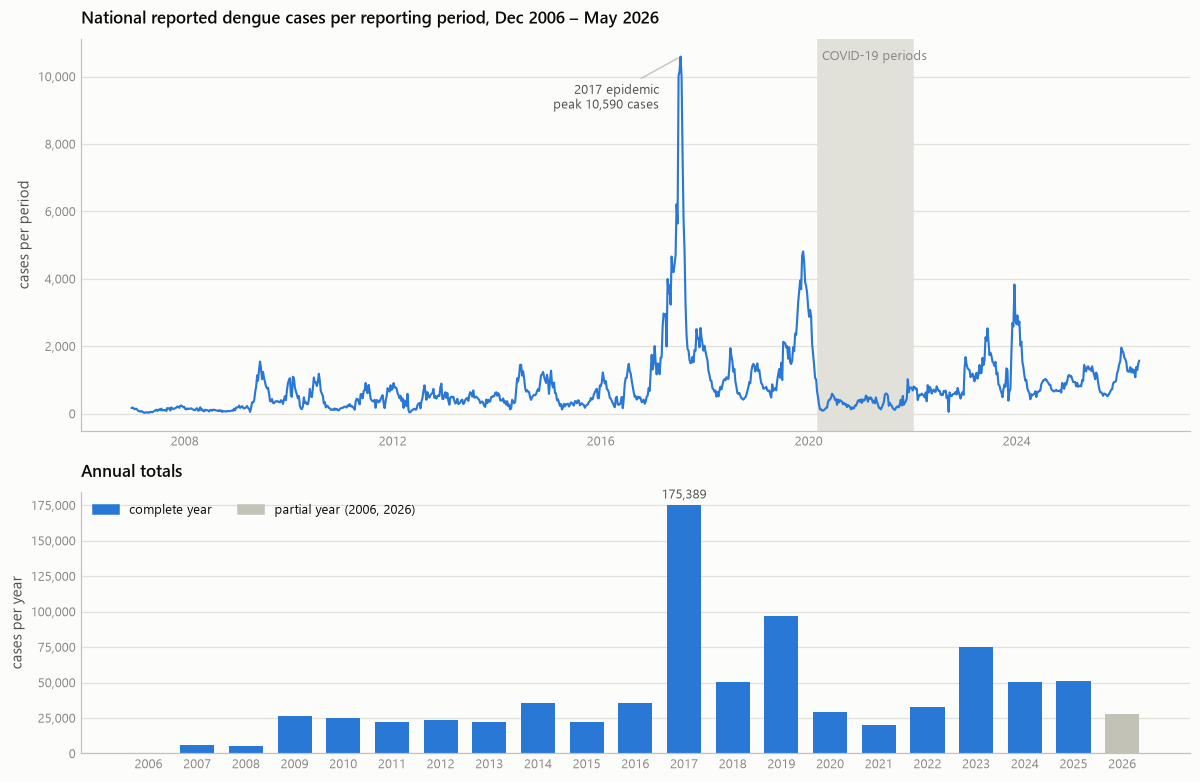

In [5]:
nat = (panel.groupby("period_id")
       .agg(start_date=("start_date", "first"), cases=("cases", "sum"))
       .reset_index())
annual = panel.groupby("year")["cases"].sum()
full = [y for y in annual.index if 2007 <= y <= 2025]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 7.2), height_ratios=[3, 2])

a0.plot(nat.start_date, nat.cases, lw=1.4, color=BLUE, solid_capstyle="round")
a0.set_title("National reported dengue cases per reporting period, "
             "Dec 2006 – May 2026")
a0.set_ylabel("cases per period")
a0.yaxis.grid(True)
a0.set_axisbelow(True)

peak = nat.loc[nat.cases.idxmax()]
a0.annotate(f"2017 epidemic\npeak {int(peak.cases):,} cases",
            xy=(peak.start_date, peak.cases), xytext=(-14, -34),
            textcoords="offset points", ha="right", color=INK2, fontsize=8.5,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.9))
cov = panel[panel.is_covid_window == 1]
a0.axvspan(cov.start_date.min(), cov.end_date.max(), color=GRID, zorder=0)
a0.text(cov.start_date.min(), a0.get_ylim()[1] * 0.97, " COVID-19 periods",
        va="top", fontsize=8.5, color=MUTED)

a1.bar(annual.index, annual.values, width=0.7,
       color=[BLUE if y in full else AXIS for y in annual.index])
a1.set_title("Annual totals")
a1.set_ylabel("cases per year")
a1.set_xticks(list(annual.index))
a1.yaxis.grid(True)
a1.set_axisbelow(True)
a1.legend(handles=[Patch(color=BLUE, label="complete year"),
                   Patch(color=AXIS, label="partial year (2006, 2026)")],
          loc="upper left", ncols=2)
a1.annotate(f"{int(annual.loc[2017]):,}", xy=(2017, annual.loc[2017]),
            xytext=(0, 4), textcoords="offset points", ha="center",
            fontsize=8.5, color=INK2)

for ax in (a0, a1):
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
fig.tight_layout()
save(fig, "fig1_national_timeseries")

## Figure 2 — seasonality, and how weak it is on its own

Dengue in Sri Lanka has two transmission peaks a year, following the two
monsoons. The band is the interquartile range across 2007–2025, and it is wide
enough to overlap most of the annual cycle — which is the descriptive form of
the result already measured in `docs/baseline.md`, where a seasonal-naive
forecast scores far worse than persistence.

Cases and rainfall are drawn on separate axes deliberately. Overlaying two
different units on one plot with two y-scales would invent an alignment that
isn't in the data.

saved results\eda\fig2_seasonality.png


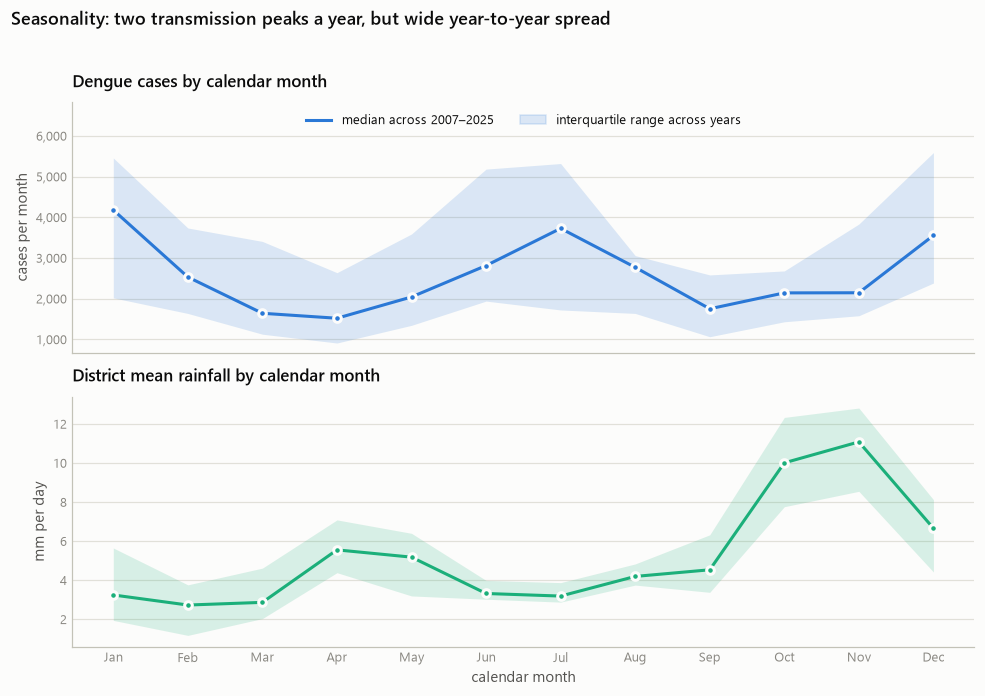

In [6]:
recent = panel[panel.year.between(2007, 2025)]


def month_band(series):
    g = series.groupby("month")
    out = pd.DataFrame({"median": g.median(),
                        "q25": g.quantile(.25),
                        "q75": g.quantile(.75)})
    return out


mon_cases = month_band(recent.groupby(["year", "month"])["cases"].sum())
mon_rain = month_band(
    recent.groupby(["year", "month"])["rainfall_daily_mean_mm"].mean())

fig, (a0, a1) = plt.subplots(2, 1, figsize=(9, 6.4), sharex=True)
for ax, tab, color, title, ylab in [
    (a0, mon_cases, BLUE, "Dengue cases by calendar month", "cases per month"),
    (a1, mon_rain, AQUA, "District mean rainfall by calendar month", "mm per day"),
]:
    ax.fill_between(tab.index, tab.q25, tab.q75, color=color, alpha=0.16, lw=0)
    ax.plot(tab.index, tab["median"], lw=2, color=color, marker="o", ms=5,
            mec=SURFACE, mew=2)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

a0.set_ylim(top=mon_cases.q75.max() * 1.22)
a0.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
a0.legend(handles=[Line2D([], [], color=BLUE, lw=2,
                          label="median across 2007–2025"),
                   Patch(color=BLUE, alpha=0.16,
                         label="interquartile range across years")],
          loc="upper center", ncols=2)
a1.set_xticks(range(1, 13))
a1.set_xticklabels(MON)
a1.set_xlabel("calendar month")

fig.suptitle("Seasonality: two transmission peaks a year, "
             "but wide year-to-year spread",
             x=0.011, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
save(fig, "fig2_seasonality")

## Figure 3 — the spatial unit and the graph over it

The left panel is the cumulative burden per district; the right is the queen
contiguity graph the GCN operates on. Districts are joined to polygons by
`gadm_gid`, never by name matching — the assertion below is what enforces that.

Note Jaffna in the north: it has degree 1 under contiguity, so it receives
almost no information through the graph. That is a known property of the
adjacency worth stating in the proposal rather than discovering later.

saved results\eda\fig3_geography.png
least connected districts:
canonical_name
Jaffna        1
Batticaloa    3
Galle         3


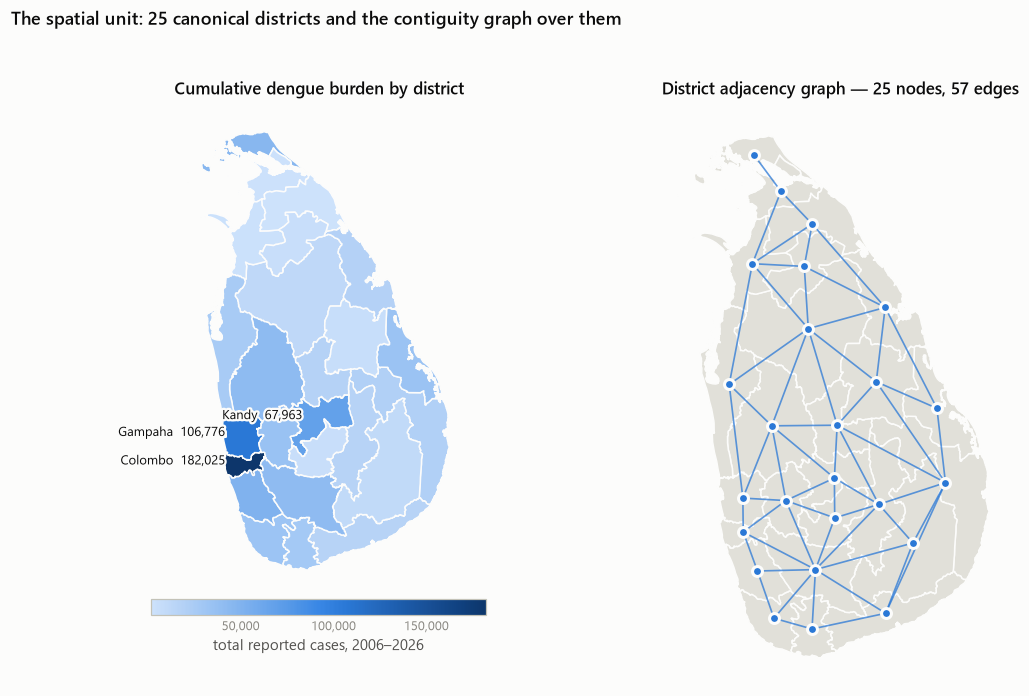

In [7]:
tot = panel.groupby(["node_id", "canonical_name"])["cases"].sum().reset_index()
geo = (gdf.merge(nodes[["node_id", "canonical_name", "gadm_gid",
                        "centroid_lat", "centroid_lon"]],
                 left_on="GID_1", right_on="gadm_gid")
       .merge(tot[["node_id", "cases"]], on="node_id"))
assert len(geo) == 25, "every district must match exactly one GADM polygon"

fig, (a0, a1) = plt.subplots(1, 2, figsize=(10.5, 6.4))

geo.plot(column="cases", cmap=SEQ, ax=a0, edgecolor=SURFACE, linewidth=1.0,
         legend=True,
         legend_kwds={"label": "total reported cases, 2006–2026",
                      "shrink": 0.55, "orientation": "horizontal", "pad": 0.01,
                      "format": "{x:,.0f}",
                      "ticks": [0, 50_000, 100_000, 150_000]})
a0.set_title("Cumulative dengue burden by district")
halo = [pe.withStroke(linewidth=3.0, foreground=SURFACE)]
for _, r in geo.nlargest(3, "cases").iterrows():
    a0.annotate(f"{r.canonical_name}  {int(r.cases):,}",
                xy=(r.centroid_lon, r.centroid_lat), xytext=(-10, 0),
                textcoords="offset points", ha="right", fontsize=8.5,
                color=INK, path_effects=halo)

geo.plot(ax=a1, facecolor=GRID, edgecolor=SURFACE, linewidth=1.0)
pos = {int(r.node_id): (r.centroid_lon, r.centroid_lat)
       for _, r in geo.iterrows()}
for i in range(len(A)):
    for j in range(i + 1, len(A)):
        if A[i, j]:
            a1.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                    color=BLUE, lw=1.1, alpha=0.75, zorder=2)
a1.scatter([p[0] for p in pos.values()], [p[1] for p in pos.values()],
           s=42, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)
a1.set_title(f"District adjacency graph — {len(A)} nodes, "
             f"{int(A.sum() // 2)} edges")

for ax in (a0, a1):
    ax.set_axis_off()
fig.suptitle("The spatial unit: 25 canonical districts and "
             "the contiguity graph over them",
             x=0.011, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "fig3_geography")

degree = pd.Series(A.sum(1).astype(int), index=nodes.canonical_name)
print("least connected districts:")
print(degree.nsmallest(3).to_string())

## Figure 4 — the burden ranking

The choropleth shows *where*; this shows *how much*, which a map cannot do
accurately because area and value are confounded on it.

saved results\eda\fig4_district_ranking.png


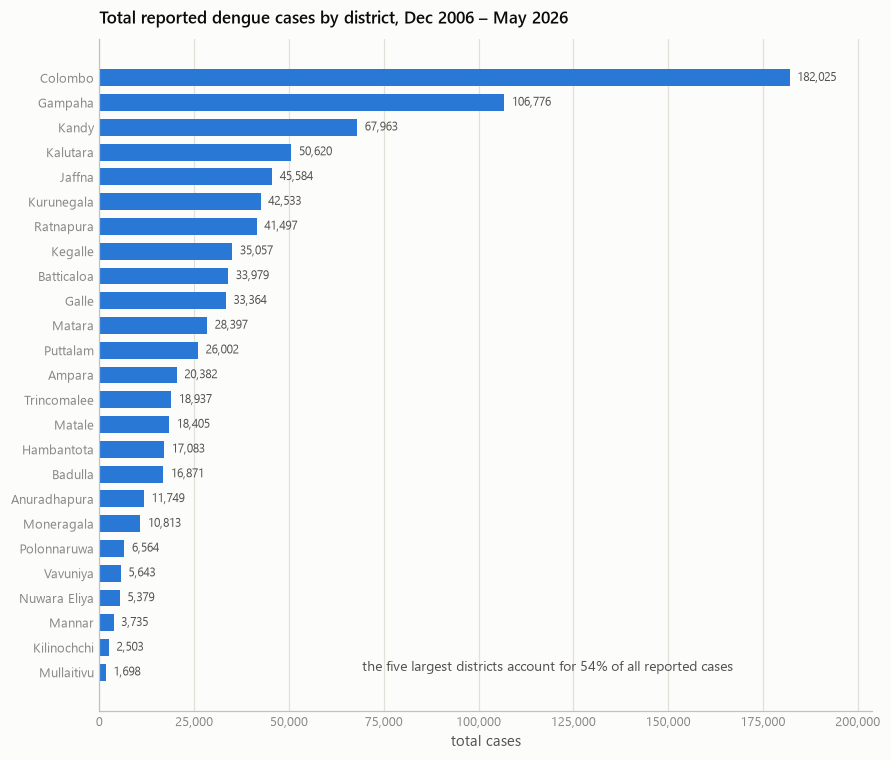

In [8]:
rank = panel.groupby("canonical_name")["cases"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8.2, 7))
ax.barh(rank.index, rank.values, color=BLUE, height=0.68)
ax.set_title("Total reported dengue cases by district, Dec 2006 – May 2026")
ax.set_xlabel("total cases")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
for name, val in rank.items():
    ax.annotate(f"{int(val):,}", xy=(val, name), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK2)
ax.set_xlim(0, rank.max() * 1.12)
ax.annotate(f"the five largest districts account for "
            f"{rank.nlargest(5).sum() / rank.sum():.0%} of all reported cases",
            xy=(0.34, 0.06), xycoords="axes fraction", fontsize=9, color=INK2)
fig.tight_layout()
save(fig, "fig4_district_ranking")

## Figure 5 — the panel itself

Every cell of the dataset, on a log scale: 25 districts down, time across.
Aggregated to months purely for legibility — the model consumes the 1 012
reporting periods.

Three structures are visible and each is a modelling consideration. The 2017
epidemic is a vertical dark band cutting every district at once, which is why a
purely spatial-diffusion story is insufficient. The northern districts
(Kilinochchi, Mullaitivu, Mannar) are near-empty before roughly 2010, reflecting
post-conflict reporting rather than absence of dengue. And the COVID-19 period
around 2020–2021 shows a broad lightening across all rows.

saved results\eda\fig5_spacetime_heatmap.png


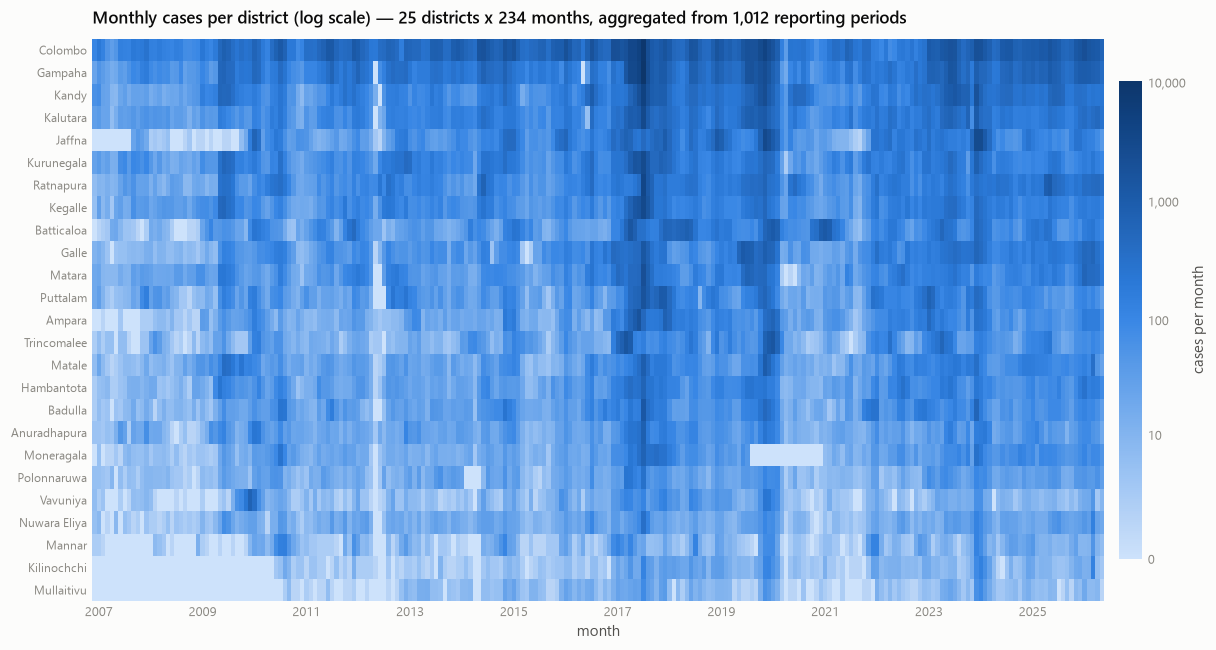

In [9]:
monthly = (panel.assign(ym=panel.start_date.dt.to_period("M"))
           .groupby(["canonical_name", "ym"])["cases"].sum().unstack("ym")
           .loc[rank.index[::-1]])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.log1p(monthly.values), aspect="auto", cmap=SEQ,
               interpolation="nearest")
ax.set_yticks(range(len(monthly)))
ax.set_yticklabels(monthly.index, fontsize=8)
jans = [(i, c.year) for i, c in enumerate(monthly.columns)
        if c.month == 1 and c.year % 2 == 1]
ax.set_xticks([i for i, _ in jans])
ax.set_xticklabels([y for _, y in jans])
ax.set_title(f"Monthly cases per district (log scale) — {len(monthly)} districts "
             f"x {monthly.shape[1]} months, aggregated from "
             f"{panel.period_id.nunique():,} reporting periods")
ax.set_xlabel("month")
for s in ax.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=ax, pad=0.012, shrink=0.85)
cb.set_label("cases per month", color=INK2)
cb.outline.set_visible(False)
ticks = [0, 10, 100, 1000, 10000]
cb.set_ticks(np.log1p(ticks))
cb.set_ticklabels([f"{t:,}" for t in ticks])

fig.tight_layout()
save(fig, "fig5_spacetime_heatmap")

## Figure 6 — the climate covariates

The ERA5-Land variables carried in the panel, as a monthly climatology with the
spread across the 25 districts. The band is the point of the figure: rainfall
varies far more between districts than temperature does, which is the
cross-sectional signal a district-level model has to exploit.

saved results\eda\fig6_climate_climatology.png


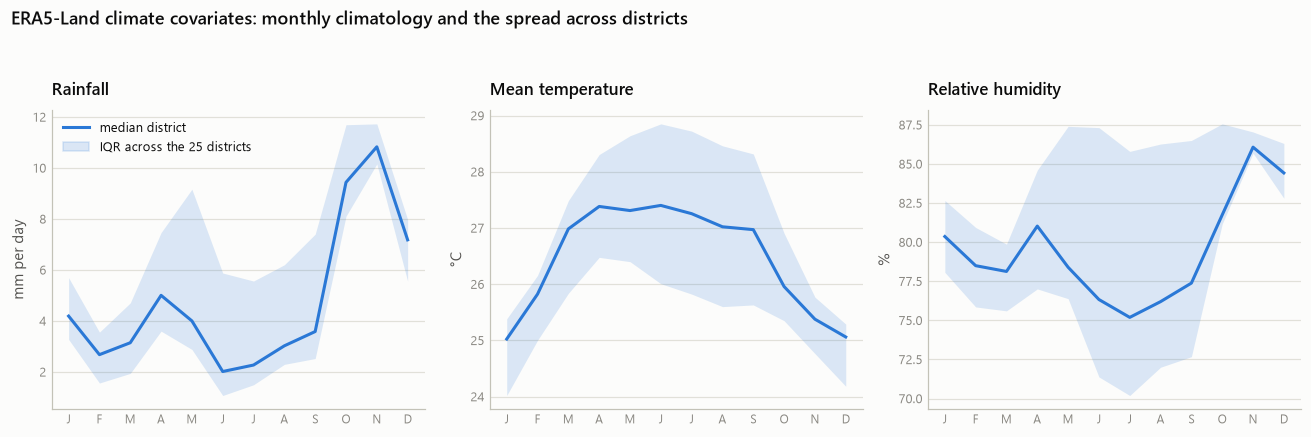

In [10]:
clim_vars = [("rainfall_daily_mean_mm", "Rainfall", "mm per day"),
             ("temperature_mean_c", "Mean temperature", "°C"),
             ("relative_humidity_mean", "Relative humidity", "%")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (col, title, unit) in zip(axes, clim_vars):
    g = panel.groupby(["month", "node_id"])[col].mean().groupby("month")
    med, q25, q75 = g.median(), g.quantile(.25), g.quantile(.75)
    ax.fill_between(med.index, q25, q75, color=BLUE, alpha=0.16, lw=0)
    ax.plot(med.index, med.values, lw=2, color=BLUE)
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([m[0] for m in MON], fontsize=8)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

axes[0].legend(handles=[Line2D([], [], color=BLUE, lw=2, label="median district"),
                        Patch(color=BLUE, alpha=0.16,
                              label="IQR across the 25 districts")],
               loc="upper left")
fig.suptitle("ERA5-Land climate covariates: monthly climatology and "
             "the spread across districts",
             x=0.011, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
save(fig, "fig6_climate_climatology")

## Figure 7 — the shape of the target

What the loss function actually has to cope with. The counts are zero-inflated
and heavy-tailed — median 10, but a maximum over 2 600 — and more than half the
national burden sits in five of the twenty-five districts.

This is the descriptive justification for two choices already made in the
baseline: predicting on a `log1p` scale, and reporting a peak-period error
alongside the mean, because an average over a distribution this skewed is
dominated by the quiet periods that matter least.

saved results\eda\fig7_target_distribution.png


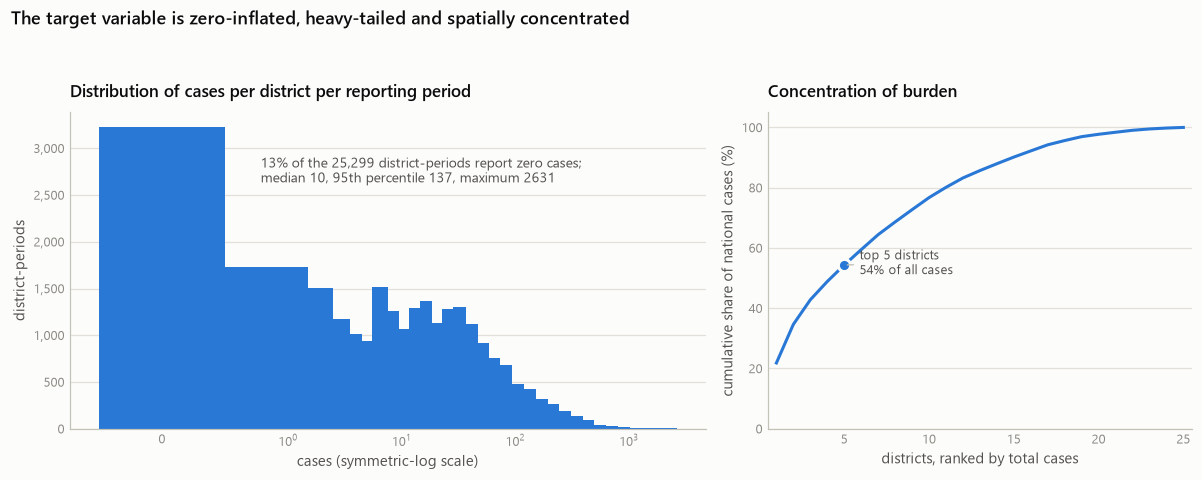

In [11]:
v = panel["cases"].dropna()
zero_share = (v == 0).mean()
# integer-snapped log bins: the counts are integers, so raw logspace edges
# would leave empty bins at the low end and print as gaps
edges = np.concatenate([[-0.5, 0.5],
                        np.unique(np.round(np.logspace(0, np.log10(v.max()), 34)))
                        + 0.5])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.4), width_ratios=[3, 2])

a0.hist(v, bins=edges, color=BLUE)
a0.set_xscale("symlog", linthresh=1)
a0.set_title("Distribution of cases per district per reporting period")
a0.set_xlabel("cases (symmetric-log scale)")
a0.set_ylabel("district-periods")
a0.yaxis.grid(True)
a0.set_axisbelow(True)
a0.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
a0.annotate(f"{zero_share:.0%} of the {len(v):,} district-periods report zero "
            f"cases;\nmedian {v.median():.0f}, 95th percentile "
            f"{v.quantile(.95):.0f}, maximum {v.max():.0f}",
            xy=(0.30, 0.86), xycoords="axes fraction", fontsize=9,
            color=INK2, va="top")

share = (rank.sort_values(ascending=False).cumsum() / rank.sum()).values
a1.plot(np.arange(1, 26), share * 100, lw=2, color=BLUE)
a1.plot([5], [share[4] * 100], "o", ms=8, color=BLUE, mec=SURFACE, mew=2)
a1.set_ylim(0, 105)
a1.set_xlim(0.5, 25.5)
a1.set_title("Concentration of burden")
a1.set_xlabel("districts, ranked by total cases")
a1.set_ylabel("cumulative share of national cases (%)")
a1.yaxis.grid(True)
a1.set_axisbelow(True)
a1.annotate(f"top 5 districts\n{share[4]:.0%} of all cases",
            xy=(5, share[4] * 100), xytext=(10, -6),
            textcoords="offset points", fontsize=8.5, color=INK2,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.9))

fig.suptitle("The target variable is zero-inflated, heavy-tailed and "
             "spatially concentrated",
             x=0.011, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
save(fig, "fig7_target_distribution")

## Files written

| Figure | File | Use in the proposal |
|---|---|---|
| 1 | `results/eda/fig1_national_timeseries.png` | the target variable and its span |
| 2 | `results/eda/fig2_seasonality.png` | seasonality is present but not sufficient |
| 3 | `results/eda/fig3_geography.png` | the spatial unit and the graph |
| 4 | `results/eda/fig4_district_ranking.png` | where the burden is |
| 5 | `results/eda/fig5_spacetime_heatmap.png` | the panel as a whole |
| 6 | `results/eda/fig6_climate_climatology.png` | the covariates |
| 7 | `results/eda/fig7_target_distribution.png` | why the loss and metrics are what they are |

Related: [`docs/climate_dataset_schema.md`](../docs/climate_dataset_schema.md),
[`docs/reporting_calendar.md`](../docs/reporting_calendar.md),
[`docs/model_tensors.md`](../docs/model_tensors.md),
[`docs/baseline.md`](../docs/baseline.md).